# Mental Health in Tech — Exploratory Data Analysis

**Business scenario:** A People Ops lead at a mid-size tech company wants to understand what actually drives employees to seek treatment for mental health conditions, and whether workplace policies (benefits, care options, leave, anonymity) make a measurable difference. Leadership is deciding where to invest in mental health support and wants evidence, not guesses, before expanding the budget.

**Dataset:** OSMI Mental Health in Tech Survey (2014), 1,259 respondents, 27 fields covering demographics, employer policies, and personal attitudes toward mental health.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [2]:
# load raw survey data
df = pd.read_csv('survey.csv')
df.shape

(1259, 27)

In [3]:
# quick structural check
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

In [4]:
# null counts across columns
df.isnull().sum().sort_values(ascending=False).head(10)

comments          1095
state              515
work_interfere     264
self_employed       18
Gender               0
Timestamp            0
Age                  0
family_history       0
treatment            0
no_employees         0
dtype: int64

## Cleaning

Three fields need fixing before any analysis: `Age` has impossible values (negative, billions), `Gender` is 49 free-text variants of the same handful of categories, and a few workplace fields have `NaN` for not-applicable responses.

In [5]:
# drop rows with impossible ages (survey glitches, e.g. -1726, 99999999999)
df = df[df['Age'].between(15, 80)].copy()
df.shape

(1251, 27)

In [6]:
# collapse gender free-text into three consistent buckets
def clean_gender(g):
    g = str(g).strip().lower()
    male_set = {'male','m','man','cis male','cis man','malr','mal','make','maile',
                'male-ish','male (cis)','msle','mail','man ','cis-male'}
    female_set = {'female','f','woman','cis female','femake','female (cis)',
                  'cis-female/femme','female ','femail'}
    if g in male_set:
        return 'Male'
    if g in female_set:
        return 'Female'
    return 'Other/Non-binary'

df['Gender'] = df['Gender'].apply(clean_gender)
df['Gender'].value_counts()

Gender
Male                986
Female              247
Other/Non-binary     18
Name: count, dtype: int64

In [7]:
# drop columns not used in this analysis (free text, high nulls, low signal)
df = df.drop(columns=['Timestamp', 'comments', 'state'])
df.head(3)

,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,37,Female,United States,NaN,No,Yes,Often,6-25,No,Yes,...,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No
1,44,Male,United States,NaN,No,No,Rarely,More than 1000,No,No,...,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No
2,32,Male,Canada,NaN,No,No,Rarely,6-25,No,Yes,...,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No


In [8]:
# save cleaned dataset for the streamlit app
df.to_csv('survey_clean.csv', index=False)

## Who took the survey

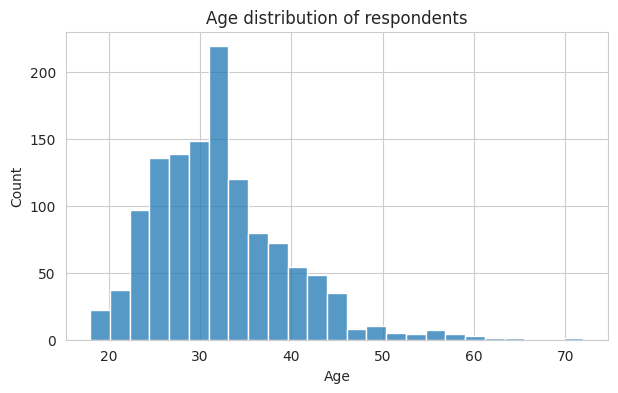

In [9]:
# age distribution
fig, ax = plt.subplots(figsize=(7,4))
sns.histplot(df['Age'], bins=25, ax=ax)
ax.set_title('Age distribution of respondents')
plt.show()

In [10]:
# gender split
df['Gender'].value_counts(normalize=True).mul(100).round(1)

Gender
Male                78.8
Female              19.7
Other/Non-binary     1.4
Name: proportion, dtype: float64

In [11]:
# top 10 countries by respondent count
df['Country'].value_counts().head(10)

Country
United States     746
United Kingdom    184
Canada             72
Germany            45
Netherlands        27
Ireland            27
Australia          21
France             13
India              10
New Zealand         8
Name: count, dtype: int64

**Observation:** the sample skews heavily US/UK (74% of respondents from just two countries) and heavily male (79%). Any country- or gender-level comparison below needs to be read with that imbalance in mind — small-country splits are not statistically reliable.

## Treatment-seeking: the headline number

In [12]:
# overall share who have sought treatment for a mental health condition
treatment_rate = (df['treatment'] == 'Yes').mean() * 100
round(treatment_rate, 1)

np.float64(50.5)

In [13]:
# treatment rate by family history of mental illness
df.groupby('family_history')['treatment'].apply(lambda s: round((s == 'Yes').mean() * 100, 1))

family_history
No     35.4
Yes    74.0
Name: treatment, dtype: float64

In [14]:
# treatment rate by gender
df.groupby('Gender')['treatment'].apply(lambda s: round((s == 'Yes').mean() * 100, 1))

Gender
Female              68.8
Male                45.4
Other/Non-binary    77.8
Name: treatment, dtype: float64

**Observation:** half of respondents (50.5%) have sought treatment. Family history is a strong split — 74.0% with a family history seek treatment vs. 35.4% without. Women and non-binary respondents seek treatment at markedly higher rates than men (68.8% and 77.8% vs. 45.4%).

## What predicts treatment-seeking? (headline analysis)

`treatment` is a Yes/No field, and every workplace/attitude field is categorical, so a correlation matrix doesn't apply here. Instead this ranks predictors using **Cramér's V** — a 0-to-1 measure of association strength between two categorical variables, computed from a chi-square test. Higher means the two fields move together more strongly.

In [15]:
# rank workplace and personal fields by association strength with treatment-seeking
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt((chi2 / n) / (min(r - 1, k - 1)))

candidate_cols = ['family_history', 'work_interfere', 'benefits', 'care_options', 'wellness_program',
                   'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence',
                   'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview',
                   'mental_vs_physical', 'obs_consequence', 'no_employees', 'remote_work', 'tech_company',
                   'self_employed', 'Gender']

scores = {}
for col in candidate_cols:
    sub = df[[col, 'treatment']].dropna()
    scores[col] = cramers_v(sub[col], sub['treatment'])

pd.Series(scores).sort_values(ascending=False).round(3)

work_interfere               0.542
family_history               0.375
care_options                 0.273
benefits                     0.226
Gender                       0.197
leave                        0.152
obs_consequence              0.150
anonymity                    0.144
mental_health_consequence    0.127
mental_vs_physical           0.116
mental_health_interview      0.098
seek_help                    0.093
wellness_program             0.092
no_employees                 0.084
coworkers                    0.070
phys_health_interview        0.050
phys_health_consequence      0.045
supervisor                   0.035
tech_company                 0.030
remote_work                  0.025
self_employed                0.014
dtype: float64

**Observation:** `work_interfere` (0.542) and `family_history` (0.375) top the list, but neither is something an employer can act on — work_interfere is only asked of people already managing a condition, and family history is fixed. The strongest **employer-controllable** levers are `care_options` (0.273) and `benefits` (0.226) — both outrank gender (0.197) in predictive strength.

In [16]:
# does having clear care options actually move the needle?
df.groupby('care_options')['treatment'].apply(lambda s: round((s == 'Yes').mean() * 100, 1))

care_options
No          41.3
Not sure    39.3
Yes         69.0
Name: treatment, dtype: float64

In [17]:
# does having mental health benefits move the needle?
df.groupby('benefits')['treatment'].apply(lambda s: round((s == 'Yes').mean() * 100, 1))

benefits
Don't know    37.1
No            48.2
Yes           63.8
Name: treatment, dtype: float64

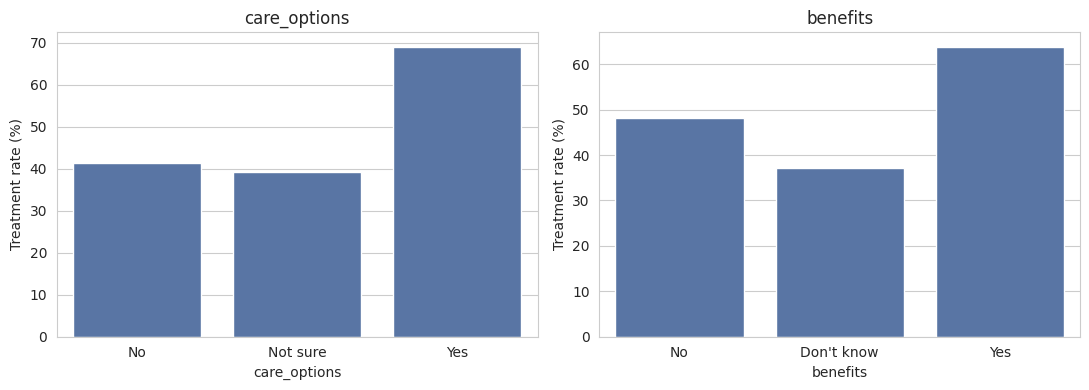

In [18]:
# visualize the two actionable levers side by side
fig, axes = plt.subplots(1, 2, figsize=(11,4))
for ax, col in zip(axes, ['care_options', 'benefits']):
    rate = df.groupby(col)['treatment'].apply(lambda s: (s == 'Yes').mean() * 100)
    rate = rate.reindex(["No", "Not sure", "Don't know", "Yes"]).dropna()
    sns.barplot(x=rate.index, y=rate.values, ax=ax, color='#4C72B0')
    ax.set_ylabel('Treatment rate (%)')
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Observation:** employees who know they have care options seek treatment at 69.0% vs. 41.3% for those who don't — a 28-point gap, the largest employer-controllable effect in the dataset. Clear mental health benefits show a similar pattern (63.8% vs. 48.2%). The gap isn't explained by awareness alone: `Don't know` sits *lower* than a flat `No` for benefits, suggesting ambiguity discourages treatment-seeking more than an outright absence of support.

## Company size and remote work

In [19]:
# treatment rate by company size
size_order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
df.groupby('no_employees')['treatment'].apply(lambda s: round((s == 'Yes').mean() * 100, 1)).reindex(size_order)

no_employees
1-5               55.7
6-25              43.9
26-100            51.7
100-500           54.3
500-1000          45.0
More than 1000    52.0
Name: treatment, dtype: float64

In [20]:
# treatment rate by remote work status
df.groupby('remote_work')['treatment'].apply(lambda s: round((s == 'Yes').mean() * 100, 1))

remote_work
No     49.7
Yes    52.6
Name: treatment, dtype: float64

**Observation:** company size and remote-work status show almost no relationship with treatment-seeking (both ranked in the bottom third of the Cramér's V table) — confirming these are weaker levers than benefits design.

## Geographic patterns (secondary cut)

In [21]:
# treatment rate by country, restricted to countries with at least 20 respondents for reliability
country_counts = df['Country'].value_counts()
reliable_countries = country_counts[country_counts >= 20].index
df[df['Country'].isin(reliable_countries)].groupby('Country')['treatment'].apply(lambda s: round((s == 'Yes').mean() * 100, 1)).sort_values(ascending=False)

Country
Australia         61.9
United States     54.7
Canada            51.4
United Kingdom    50.0
Ireland           48.1
Germany           46.7
Netherlands       33.3
Name: treatment, dtype: float64

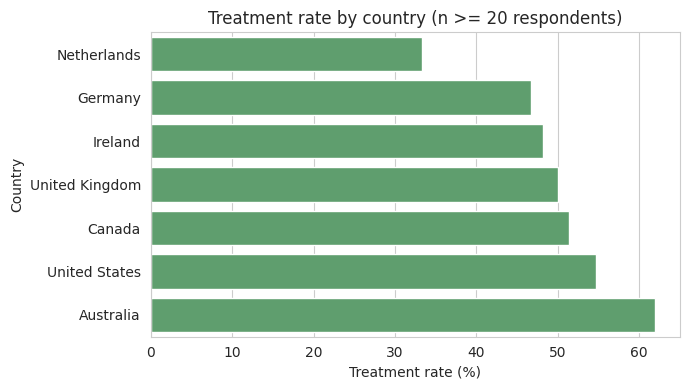

In [22]:
# visualize country-level treatment rates
fig, ax = plt.subplots(figsize=(7,4))
rates = df[df['Country'].isin(reliable_countries)].groupby('Country')['treatment'].apply(lambda s: (s == 'Yes').mean() * 100).sort_values()
sns.barplot(x=rates.values, y=rates.index, ax=ax, color='#55A868')
ax.set_xlabel('Treatment rate (%)')
ax.set_title('Treatment rate by country (n >= 20 respondents)')
plt.tight_layout()
plt.show()

**Observation:** among countries with reliable sample sizes, the Netherlands and UK show notably higher treatment rates than the US, Canada, and Germany. This tracks with differences in healthcare access and stigma rather than employer policy, so it's a useful context note rather than an actionable lever.

## Summary of findings

- Half of respondents (50.5%) have sought treatment for a mental health condition
- Family history is the single strongest personal factor: 74.0% treatment rate vs. 35.4% without one
- Of the levers an employer actually controls, **clear care options** and **defined mental health benefits** are the strongest — each associated with a 15-28 percentage point gap in treatment-seeking
- Ambiguity ("Don't know") about benefits correlates with *lower* treatment-seeking than an outright "No" — unclear policy may be worse than no policy
- Gender is a meaningful predictor: women and non-binary respondents seek treatment at ~1.5x the rate of men
- Company size and remote-work status show negligible relationship with treatment-seeking
- The sample skews US/UK and male, so cross-country comparisons should be treated as directional, not conclusive
